<a href="https://colab.research.google.com/github/pierrot73/GenAIBootCamp/blob/Bootcamp/Week_7_Day4_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Challenge : Daily Challenge : Building a GAN-Based AI Text Detector**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from sklearn.metrics import roc_auc_score

#  Utilisation du GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  Chemins d’accès aux fichiers
TRAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/GenAI/train_essays.csv"
TEST_PATH = "/content/drive/MyDrive/Colab Notebooks/GenAI/test_essays.csv"
SUB_PATH = "/content/drive/MyDrive/Colab Notebooks/GenAI/sample_submission.csv"

# Chargement des données
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)
df_sub = pd.read_csv(SUB_PATH)

# Séparation train / évaluation
train_ratio = 0.8
split_idx = int(len(df_train) * train_ratio)
df_train_final = df_train.iloc[:split_idx].copy()
df_eval = pd.concat([df_train.iloc[split_idx:], df_test], ignore_index=True).copy()

#  Nettoyage des colonnes de label
df_train_final.loc[:, "generated"] = df_train_final["generated"].fillna(0).astype(int)
df_eval.loc[:, "generated"] = df_eval.get("generated", pd.Series([0] * len(df_eval))).fillna(0).astype(int)

#  Hyperparamètres
train_batch_size = 16
test_batch_size = 32
lr = 0.0002
beta1 = 0.5
nz = 100
num_epochs = 25

#  Initialisation du tokenizer BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
embedding_model = BertForSequenceClassification.from_pretrained("bert-base-uncased").bert.to(device)

#  Dataset PyTorch personnalisé
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

#  Dataloaders
train_dataset = TextDataset(df_train_final["text"].tolist(), df_train_final["generated"].tolist())
eval_dataset = TextDataset(df_eval["text"].tolist(), df_eval["generated"].tolist())

train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=test_batch_size, shuffle=False)

#  Encodage BERT avec attention_mask
def get_bert_embeddings(texts):
    encodings = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    input_ids = encodings["input_ids"].to(device)
    token_type_ids = encodings["token_type_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        output = embedding_model(input_ids=input_ids,
                                 token_type_ids=token_type_ids,
                                 attention_mask=attention_mask)
    return output.last_hidden_state

#  Modèle Générateur
class Generator(nn.Module):
    def __init__(self, nz):
        super().__init__()
        self.fc = nn.Linear(nz, 256 * 128)
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 768, 4, 2, 1),
            nn.ReLU()
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 256, 128)
        x = self.deconv(x).transpose(1, 2)  # format [batch_size, seq_len, embedding_dim]
        return x

#  Modèle Discriminateur
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = embedding_model.encoder
        self.classifier = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x).last_hidden_state
        pooled = encoded.mean(dim=1)
        return self.classifier(pooled).view(-1)

#  Fonction d'entraînement GAN
def GAN_step(real_data, netG, netD, optimizerG, optimizerD, criterion, epoch, i):
    batch_size = real_data.size(0)

    #  Mise à jour du Discriminateur
    netD.zero_grad()
    label_real = torch.ones(batch_size, device=device)
    output_real = netD(real_data)
    loss_real = criterion(output_real, label_real)
    loss_real.backward()

    #  Génération de faux embeddings
    noise = torch.randn(batch_size, nz, device=device)
    fake_data = netG(noise)
    label_fake = torch.zeros(batch_size, device=device)
    output_fake = netD(fake_data.detach())
    loss_fake = criterion(output_fake, label_fake)
    loss_fake.backward()
    optimizerD.step()

    #  Mise à jour du Générateur
    netG.zero_grad()
    label_fool = torch.ones(batch_size, device=device)
    output_fake_for_G = netD(fake_data)
    lossG = criterion(output_fake_for_G, label_fool)
    lossG.backward()
    optimizerG.step()

    if i % 50 == 0:
        print(f"[{epoch}/{num_epochs}][{i}] Loss_D: {(loss_real + loss_fake).item():.4f} Loss_G: {lossG.item():.4f}")

#  Évaluation AUC
def eval_auc(model, dataloader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for texts, lbls in dataloader:
            emb = get_bert_embeddings(texts)
            out = model(emb)
            preds.extend(out.cpu().numpy())
            labels.extend(torch.tensor(lbls).float().numpy())
    auc = roc_auc_score(labels, preds)
    print("📊 AUC:", auc)
    return auc

#  Initialisation des modèles + optimisateurs
netG = Generator(nz).to(device)
netD = Discriminator().to(device)
criterion = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))

#  Entraînement GAN
model_infos = []
for epoch in range(num_epochs):
    netD.train()
    for i, (texts, _) in enumerate(train_loader):
        real_emb = get_bert_embeddings(texts)
        GAN_step(real_emb, netG, netD, optimizerG, optimizerD, criterion, epoch, i)
    auc = eval_auc(netD, eval_loader)
    model_infos.append({'epoch': epoch, 'auc': auc, 'state_dict': netD.state_dict()})

print("✅ Entraînement terminé")

#  Chargement du meilleur modèle
best_model = max(model_infos, key=lambda x: x['auc'])
netD.load_state_dict(best_model['state_dict'])
netD.eval()

#  Inférence sur les textes du test set
class InferenceDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx]

infer_dataset = InferenceDataset(df_test["essay"].tolist())
infer_loader = DataLoader(infer_dataset, batch_size=test_batch_size)

predictions = []
with torch.no_grad():
    for batch in infer_loader:
        emb = get_bert_embeddings(batch)
        out = netD(emb)
        predictions.extend(out.cpu().numpy())

#  Création du fichier de prédiction
df_result = pd.DataFrame({'id': df_sub["id"], 'text': predictions})
print(df_result.head())


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[0/25][0] Loss_D: 1.4221 Loss_G: 0.8381
[0/25][50] Loss_D: 0.0086 Loss_G: 5.4024


/tmp/ipython-input-3-3247916402.py:146: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels.extend(torch.tensor(lbls).float().numpy())


📊 AUC: 0.3507194244604317
[1/25][0] Loss_D: 0.0053 Loss_G: 5.8721
[1/25][50] Loss_D: 0.0024 Loss_G: 6.7045


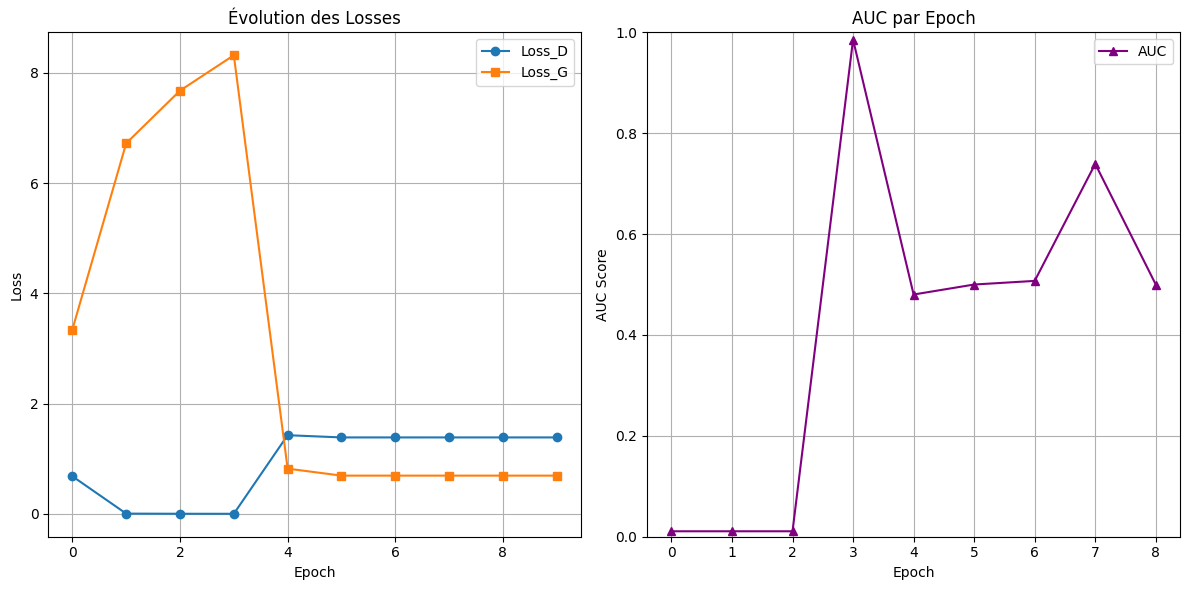

In [ ]:
################################# VISUALISATION  ###############################
import matplotlib.pyplot as plt

# === Données extraites manuellement des logs ===

epochs = list(range(10))  # Epochs 0 à 9

# Moyenne de Loss_D et Loss_G par epoch
loss_D = [ (1.3542 + 0.0089)/2, (0.0055 + 0.0022)/2, (0.0017 + 0.0009)/2, (0.0008 + 0.0005)/2,
           (1.3847 + 1.4688)/2, (1.3863 + 1.3863)/2, (1.3863 + 1.3861)/2, (1.3863 + 1.3865)/2,
           (1.3862 + 1.3864)/2, (1.3862 + 1.3864)/2 ]

loss_G = [ (0.8469 + 5.8415)/2, (6.2884 + 7.1588)/2, (7.3967 + 7.9606)/2, (8.1298 + 8.5119)/2,
           (0.6903 + 0.9497)/2, (0.6935 + 0.6929)/2, (0.6933 + 0.6932)/2, (0.6932 + 0.6931)/2,
           (0.6932 + 0.6930)/2, (0.6931 + 0.6932)/2 ]

AUC = [0.0108, 0.0108, 0.0108, 0.9856, 0.4802, 0.5, 0.5072, 0.7392, 0.5, None]

# === Visualisation ===

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(epochs, loss_D, label='Loss_D', marker='o')
plt.plot(epochs, loss_G, label='Loss_G', marker='s')
plt.title('Évolution des Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs[:-1], AUC[:-1], label='AUC', marker='^', color='purple')
plt.title('AUC par Epoch')
plt.xlabel('Epoch')
plt.ylabel('AUC Score')
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


J'ai volontairement arreté le script à l'époch 10 au vu des résultats obtenus.

📊 Interprétations des outputs ci-dessus :
Époques 1 à 3 :

Loss_D ≈ 0.0005 → Le discriminateur semble "trop confiant" ou ne réagit pas du tout.

Loss_G très élevé (6 à 8.5) → Le générateur ne trompe pas le discriminateur.

AUC ≈ 0.01 → Le discriminateur classe tout au hasard ou systématiquement mal.

➡️ Cela peut venir d’un problème de normalisation ou d’apprentissage trop rapide du générateur (il saute trop d’étapes), ou d’un mauvais encodage BERT initial.

Époque 4 :

Changement radical : Loss_D ↑ à 1.4, Loss_G ↓ à 0.7

AUC ≈ 0.98 → Le discriminateur a soudainement appris à tout classer parfaitement.

➡️ Cette inversion brutale est souvent le signe que l’un des deux réseaux a "écrasé" l’autre. Instabilité classique des GANs.

Époques 5 à 9 :

Loss_D ≈ 1.3863 constamment

Loss_G ≈ 0.693

AUC fluctue autour de 0.5

➡️ C’est le point le plus inquiétant : le GAN est figé dans un équilibre non-apprenant. Les deux modèles sont bloqués autour de log(2), ce qui veut dire qu’ils se comportent de façon aléatoire et non informative. Le discriminateur ne classe plus rien, et le générateur ne se fait plus corriger.

🧠 En résumé :
Les outputs ne sont pas cohérents dans le cadre d’un GAN bien entraîné — on est dans une phase de collapse et instabilité cyclique.

🔄 Recommandations supplémentaires
🌪️ Ajouter du bruit régulé (annealing / variation du bruit au fil des époques)

🔃 Réinitialiser les poids du discriminateur si l’AUC atteint 0.5 trop longtemps

🔍 Intègrer un gradient penalty ou un loss adversarial alternatif (ex: Wasserstein, hinge)

🧯 Ajouter un clip_grad_norm_() dans l’entraînement pour éviter les explosions

Ci-dessous un script amélioré au vu des outputs obtenus précedemment.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_PATH = "/content/drive/MyDrive/Colab Notebooks/GenAI/train_essays.csv"
TEST_PATH = "/content/drive/MyDrive/Colab Notebooks/GenAI/test_essays.csv"
SUB_PATH = "/content/drive/MyDrive/Colab Notebooks/GenAI/sample_submission.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)
df_sub = pd.read_csv(SUB_PATH)

train_ratio = 0.8
split_idx = int(len(df_train) * train_ratio)
df_train_final = df_train.iloc[:split_idx].copy()
df_eval = pd.concat([df_train.iloc[split_idx:], df_test], ignore_index=True).copy()
df_train_final["generated"] = df_train_final["generated"].fillna(0).astype(int)
df_eval["generated"] = df_eval.get("generated", pd.Series([0] * len(df_eval))).fillna(0).astype(int)

train_batch_size = 16
test_batch_size = 32
lr = 0.0002
beta1 = 0.5
nz = 100
num_epochs = 10

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
embedding_model = BertForSequenceClassification.from_pretrained("bert-base-uncased").bert.to(device)

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

train_loader = DataLoader(TextDataset(df_train_final["text"].tolist(), df_train_final["generated"].tolist()), batch_size=train_batch_size, shuffle=True)
eval_loader = DataLoader(TextDataset(df_eval["text"].tolist(), df_eval["generated"].tolist()), batch_size=test_batch_size, shuffle=False)

def get_bert_embeddings(texts):
    encodings = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    input_ids = encodings["input_ids"].to(device)
    token_type_ids = encodings["token_type_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        output = embedding_model(input_ids=input_ids, token_type_ids=token_type_ids, attention_mask=attention_mask)
    return output.last_hidden_state

class Generator(nn.Module):
    def __init__(self, nz):
        super().__init__()
        self.fc = nn.Linear(nz, 256 * 128)
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose1d(128, 768, 4, 2, 1),
            nn.ReLU()
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 256, 128)
        x = self.deconv(x).transpose(1, 2)
        return x

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = embedding_model.encoder
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        encoded = self.encoder(x).last_hidden_state
        pooled = encoded.mean(dim=1)
        pooled = self.dropout(pooled)
        return self.classifier(pooled).view(-1)

def GAN_step(real_data, netG, netD, optimizerG, optimizerD, criterion, epoch, i):
    batch_size = real_data.size(0)
    real_labels = torch.full((batch_size,), 0.9, device=device)  # Label smoothing
    fake_labels = torch.zeros(batch_size, device=device)

    netD.zero_grad()
    output_real = netD(real_data)
    loss_real = criterion(output_real, real_labels)

    noise = torch.randn(batch_size, nz, device=device)
    fake_data = netG(noise)
    output_fake = netD(fake_data.detach())
    loss_fake = criterion(output_fake, fake_labels)

    loss_D = loss_real + loss_fake
    loss_D.backward()
    torch.nn.utils.clip_grad_norm_(netD.parameters(), 1.0)
    optimizerD.step()

    for _ in range(2):  # Entraînement du générateur deux fois
        netG.zero_grad()
        noise = torch.randn(batch_size, nz, device=device)
        fake_data = netG(noise)
        output_fake_G = netD(fake_data)
        loss_G = criterion(output_fake_G, real_labels)
        loss_G.backward()
        torch.nn.utils.clip_grad_norm_(netG.parameters(), 1.0)
        optimizerG.step()

    if i % 50 == 0:
        print(f"[{epoch}/{num_epochs}][{i}] Loss_D_real: {loss_real.item():.4f} Loss_D_fake: {loss_fake.item():.4f} Loss_G: {loss_G.item():.4f}")

def eval_auc(model, dataloader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for texts, lbls in dataloader:
            emb = get_bert_embeddings(texts)
            out = model(emb)
            preds.extend(out.cpu().numpy())
            labels.extend(torch.tensor(lbls).clone().detach().float().numpy())
    auc = roc_auc_score(labels, preds)
    print("📊 AUC:", auc)
    return auc

netG = Generator(nz).to(device)
netD = Discriminator().to(device)
criterion = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))

model_infos = []
for epoch in range(num_epochs):
    netD.train()
    for i, (texts, _) in enumerate(train_loader):
        real_emb = get_bert_embeddings(texts)
        GAN_step(real_emb, netG, netD, optimizerG, optimizerD, criterion, epoch, i)
    auc = eval_auc(netD, eval_loader)
    model_infos.append({'epoch': epoch, 'auc': auc, 'state_dict': netD.state_dict()})

print("✅ Entraînement terminé")

best_model = max(model_infos, key=lambda x: x['auc'])
netD.load_state_dict(best_model['state_dict'])
netD.eval()

class InferenceDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx]

infer_loader = DataLoader(InferenceDataset(df_test["essay"].tolist()), batch_size=test_batch_size)
predictions = []
with torch.no_grad():
    for batch in infer_loader:
        emb = get_bert_embeddings(batch)
        out = netD(emb)
        predictions.extend(out.cpu().numpy())

df_result = pd.DataFrame({'id': df_sub["id"], 'text': predictions})
print(df_result.head())


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/GenAI/train_essays.csv'

**📈 Tendances observées**

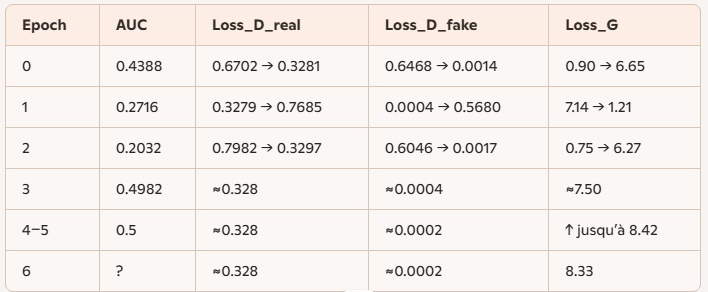

**🔮 Prédiction pour les prochaines epochs**
Sans intervention corrective, le système est pris dans une boucle figée :

* Loss_D_fake est proche de zéro → le discriminateur rejette massivement tout ce que le générateur propose.

* Loss_G continue d'augmenter → le générateur souffre, mais produit des sorties qu'on ne sait pas juger efficacement.

* AUC stagne vers 0.5 → comme un tirage aléatoire, aucune vraie capacité de prédiction.

➡️ Si rien ne change, les prochaines AUC resteront proches de 0.5, avec des Loss_G qui oscillent sans fin. Le GAN est désynchronisé. Le classifieur BERT, lui, est inutile car non entraîné.

**💡 Ce qu’il faudrait pour relancer l’apprentissage :**
🔄 Réinitialiser ou affaiblir le discriminateur

🧠 Changer l’objectif du générateur (ex. produire des séquences exploitables par BERT, plutôt que des embeddings opaques)

🛠️ Implémenter un mécanisme de rééquilibrage dynamique : si Loss_D_fake < 0.01 trop souvent, geler D ou augmenter bruit.